#### Step 1 导入相关包

In [38]:
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import numpy as np

In [39]:
# 设置格式
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

#### Step 2 加载数据

In [40]:
p2psim_top_max_sim = pd.read_csv('./citations_result/p2psim_top_max_sim_applicant.csv')
p2psim_top_max_sim

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15804\2999308042.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  p2psim_top_max_sim = pd.read_csv('./citations_result/p2psim_top_max_sim_applicant.csv')


,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
0,5751830,10000000,0.675,cited by applicant,10000000,2018.0,9.0,0
1,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0
2,8124241,10000002,0.709,cited by applicant,10000002,2018.0,0.0,0
3,9352506,10000003,0.794,cited by applicant,10000003,2018.0,1.0,0
4,5632133,10000004,0.661,cited by examiner,10000004,2018.0,0.0,0
...,...,...,...,...,...,...,...,...
5171992,6584922,9975748,0.796,cited by examiner,9975748,2018.0,0.0,0
5171993,6173941,9975749,0.805,cited by applicant,9975749,2018.0,1.0,0
5171994,6695568,9975750,0.571,cited by applicant,9975750,2018.0,12.0,0
5171995,5607004,9975751,0.737,cited by examiner,9975751,2018.0,0.0,0


In [41]:
p2psim_top_max_sim[p2psim_top_max_sim['patent_year']==2019][p2psim_top_max_sim['is_top']==1]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15804\796096953.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  p2psim_top_max_sim[p2psim_top_max_sim['patent_year']==2019][p2psim_top_max_sim['is_top']==1]


,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
139804,9133472,10165744,0.872,cited by applicant,10165744,2019.0,31.0,1
139807,8759636,10165747,0.913,cited by applicant,10165747,2019.0,3.0,1
139811,8530726,10165751,0.853,cited by applicant,10165751,2019.0,0.0,1
139853,9010335,10165799,0.651,cited by examiner,10165799,2019.0,0.0,1
139878,7533477,10165824,0.748,cited by applicant,10165824,2019.0,7.0,1
...,...,...,...,...,...,...,...,...
438703,9607914,10524372,0.658,cited by applicant,10524372,2019.0,0.0,1
438715,8804091,10524384,0.843,cited by applicant,10524384,2019.0,50.0,1
438723,9420727,10524394,0.701,cited by examiner,10524394,2019.0,0.0,1
438726,9648790,10524397,0.968,cited by examiner,10524397,2019.0,50.0,1


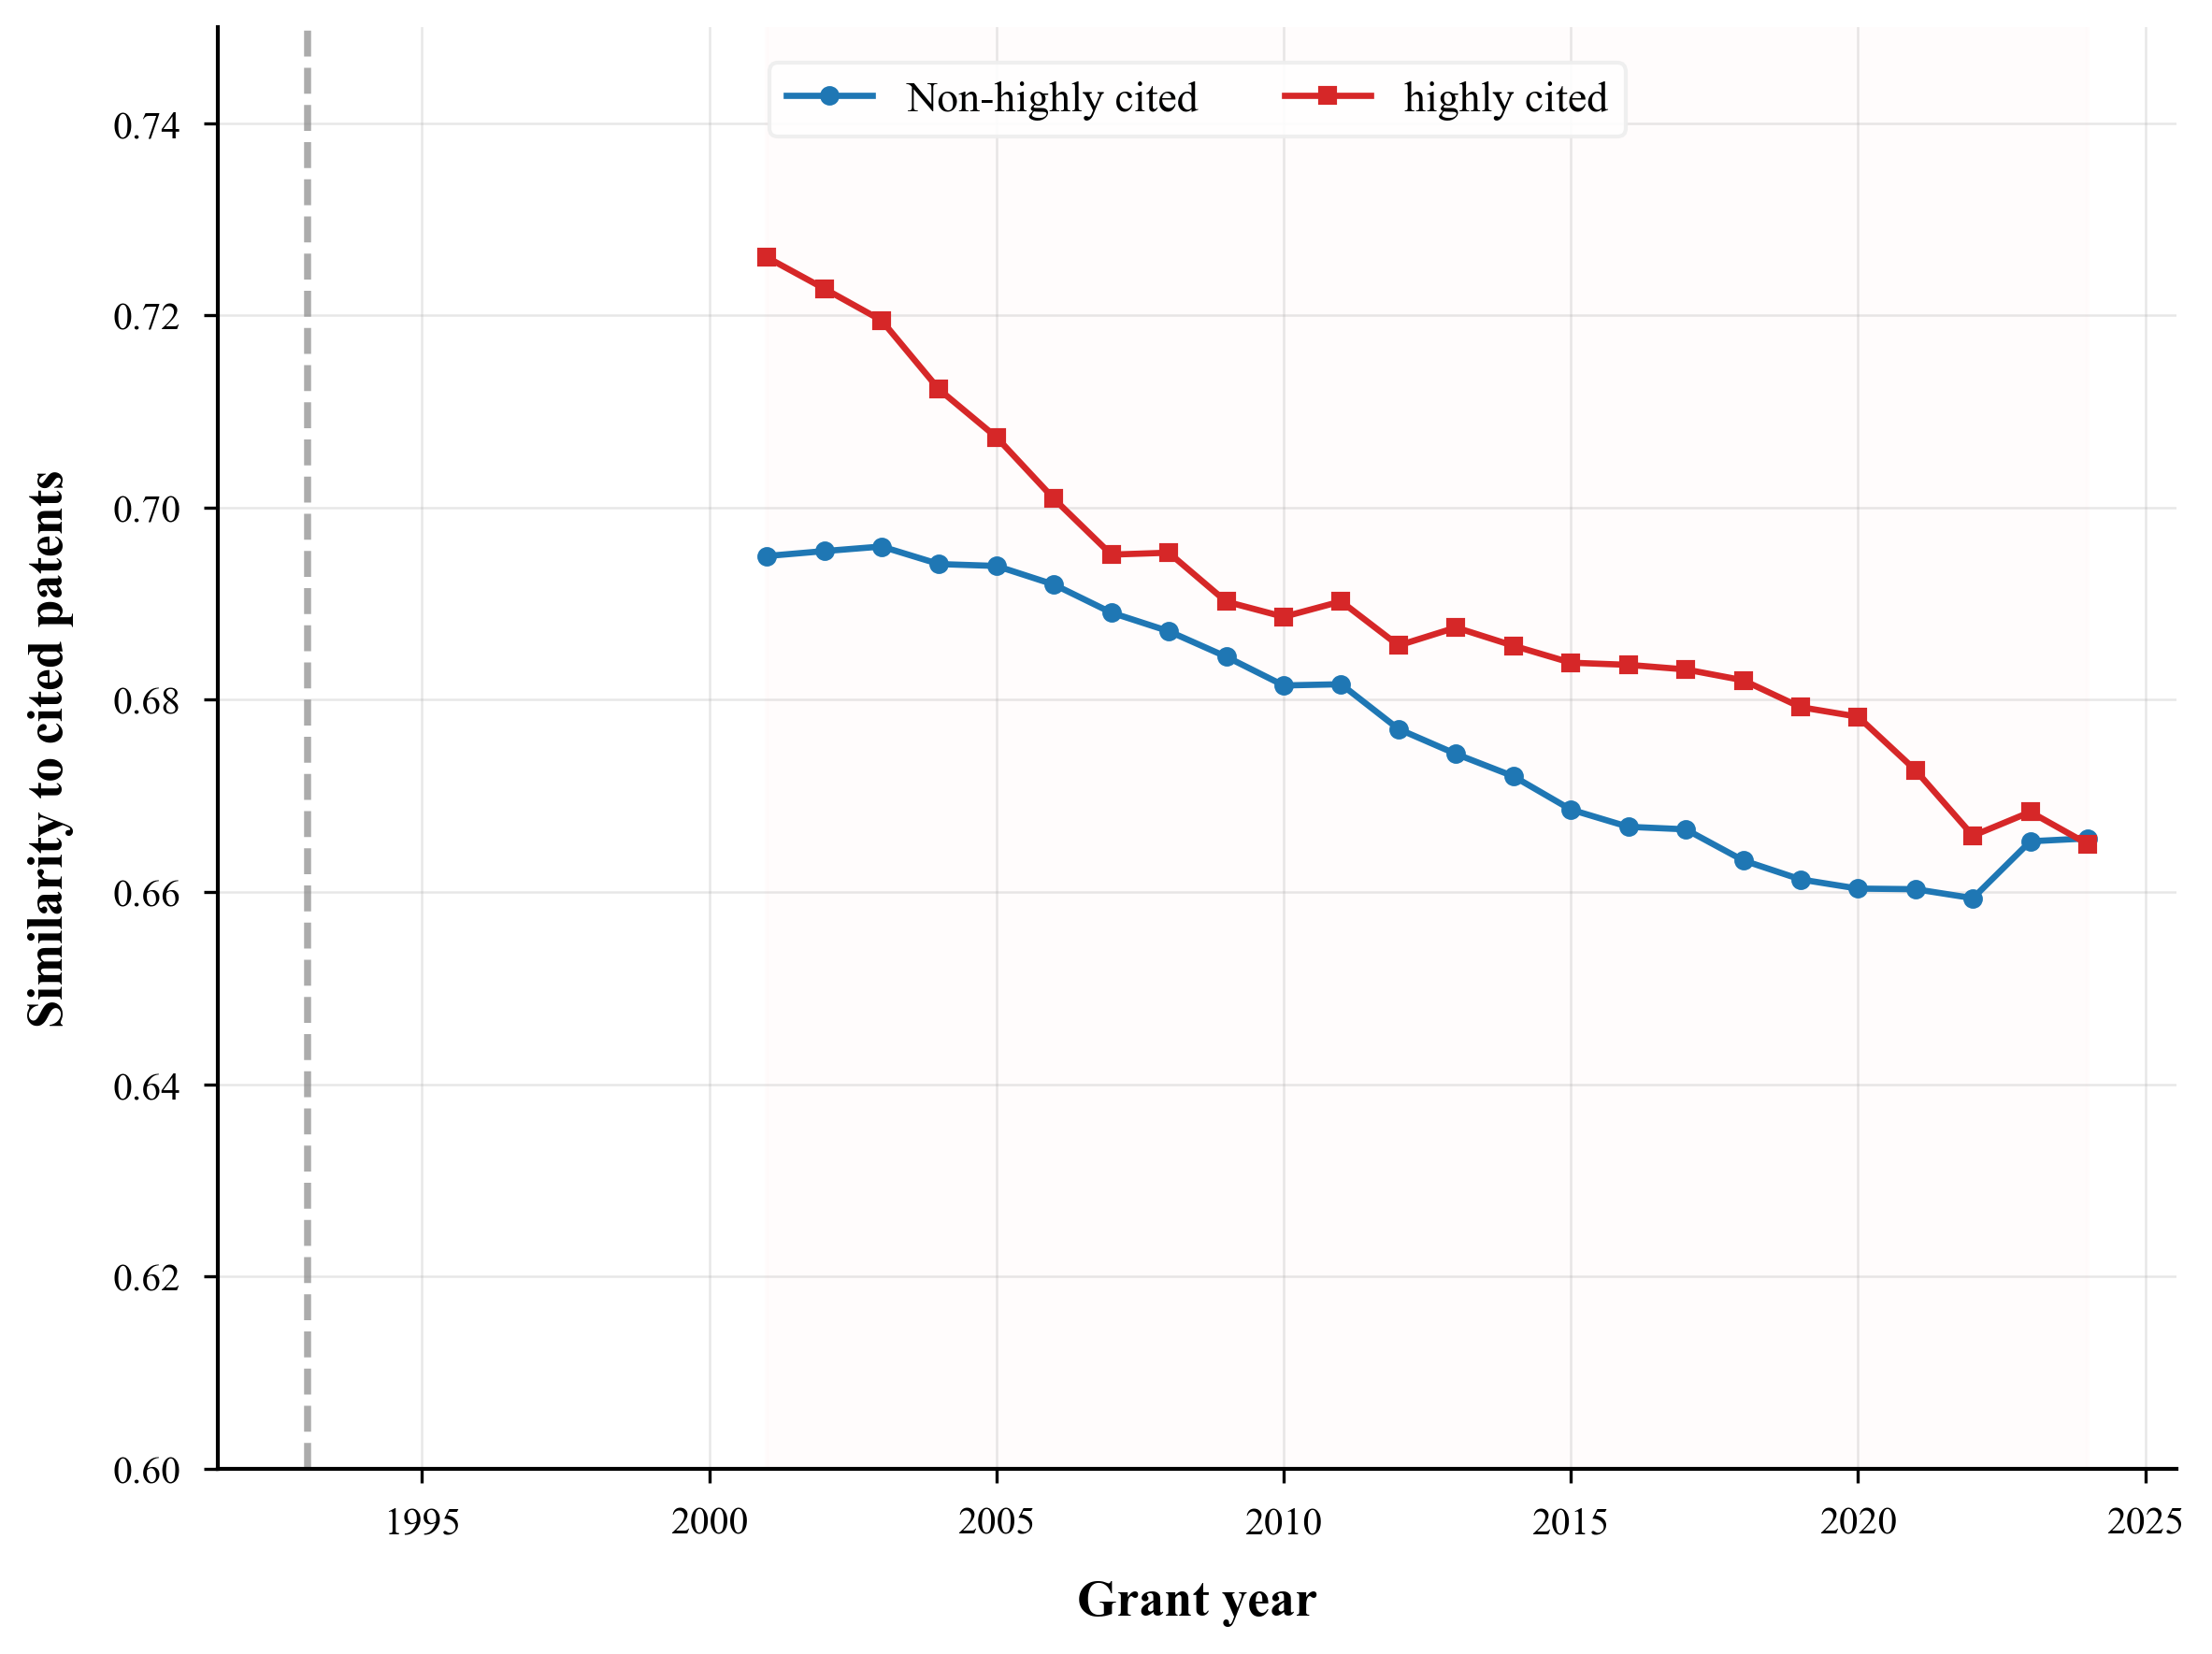

In [42]:
# 1) 按 is_top 分组，取每年平均 similarity
year_sim = (
    p2psim_top_max_sim
    .query("1980 <= patent_year <= 2024")
    .assign(group=lambda x: np.where(x['is_top'] == 0, 'non-top', 'top'))
    .groupby(['patent_year', 'group'])['sim']
    .mean()
    .unstack('group')          # pivot 成列
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300) 

# --------------------------
# 关键修复：fill_between 参数修正（ymin→y2，ymax→y1）
# --------------------------
# 左侧填充（1980-1993）：浅蓝色，低透明度
ax.fill_between(
    x=year_sim.index[year_sim.index <= 1993],  # x范围：1993及之前
    y2=0,  # 填充下限（原ymin，对应fill_between的y2参数）
    y1=year_sim.max().max() * 1.05,  # 填充上限（原ymax，对应fill_between的y1参数）
    color='#E8F4FD',  # 浅蓝（柔和不刺眼）
    alpha=0.18,  # 低透明度，不干扰折线
    zorder=0  # 图层优先级：0（最下层）
)

# 右侧填充（1993-2024）：浅红色，低透明度
ax.fill_between(
    x=year_sim.index[year_sim.index >= 1993],  # x范围：1993及之后
    y2=0,  # 填充下限
    y1=year_sim.max().max() * 1.05,  # 填充上限
    color='#FFF2F2',  # 浅红（与左侧区分）
    alpha=0.18,
    zorder=0
)

ax.plot(
    year_sim.index, 
    year_sim['non-top'],
    color='#1f77b4', 
    marker='o',
    lw=1.6, 
    ms=4, 
    label='Non-highly cited',
    zorder=3  # 折线在最上层
)

ax.plot(
    year_sim.index, 
    year_sim['top'],
    color='#d62728', 
    marker='s',
    lw=1.6, 
    ms=4, 
    label='highly cited',
    zorder=3  # 折线在最上层
)

# --------------------------
# 1993年垂直分界线（保持不变）
# --------------------------
ax.axvline(
    x=1993, 
    color='#888888',  # 中灰色
    linestyle='--',  # 虚线
    linewidth=1.8,
    alpha=0.7,
    zorder=1  # 分界线在填充之上、折线之下
)

# --------------------------
# 原有美化优化（保持不变）
# --------------------------
ax.set_xlabel('Grant year', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Similarity to cited patents', fontsize=13, fontweight='bold', labelpad=10)

# 网格优化
ax.grid(alpha=0.3, lw=0.6, zorder=1)

# 精简边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# 图例优化
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=2,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='#EEEEEE',
)

# 刻度优化
ax.tick_params(axis='x', labelsize=10, pad=6)
ax.tick_params(axis='y', labelsize=10, pad=6)
ax.set_ylim(0.6,0.75)

ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# 释放内存
plt.close('all')

In [43]:
p2psim_top_max_sim['patent_id'] = p2psim_top_max_sim['patent_id'].astype('str')
p2psim_top_max_sim['cited_id'] = p2psim_top_max_sim['cited_id'].astype('str')

#### Step 4 加载颠覆性指数

In [7]:
df_di = pd.read_csv('./citations_result/CD5_index.csv')

In [8]:
df_di['patent_id'] = df_di['patent_id'].astype('str')

In [9]:
df_di

,patent_id,cd5_index
0,D985971,-0.038462
1,D403821,-0.086957
2,D727728,-0.011364
3,D448581,-0.500000
4,D610061,0.095238
...,...,...
5245752,D449642,-0.050000
5245753,D632430,-0.250000
5245754,D543980,-0.050000
5245755,D863024,-0.034335


In [44]:
p2psim_top_max_sim

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top
0,5751830,10000000,0.675,cited by applicant,10000000,2018.0,9.0,0
1,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0
2,8124241,10000002,0.709,cited by applicant,10000002,2018.0,0.0,0
3,9352506,10000003,0.794,cited by applicant,10000003,2018.0,1.0,0
4,5632133,10000004,0.661,cited by examiner,10000004,2018.0,0.0,0
...,...,...,...,...,...,...,...,...
5171992,6584922,9975748,0.796,cited by examiner,9975748,2018.0,0.0,0
5171993,6173941,9975749,0.805,cited by applicant,9975749,2018.0,1.0,0
5171994,6695568,9975750,0.571,cited by applicant,9975750,2018.0,12.0,0
5171995,5607004,9975751,0.737,cited by examiner,9975751,2018.0,0.0,0


In [45]:
df_merged = (
    p2psim_top_max_sim
    .merge(
        df_di.rename(columns={"patent_id": "cited_id"}),
        on="cited_id",
        how="left"
    )
)

In [46]:
df_merged

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top,cd5_index
0,5751830,10000000,0.675,cited by applicant,10000000,2018.0,9.0,0,0.025424
1,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0,0.333333
2,8124241,10000002,0.709,cited by applicant,10000002,2018.0,0.0,0,0.090909
3,9352506,10000003,0.794,cited by applicant,10000003,2018.0,1.0,0,0.222222
4,5632133,10000004,0.661,cited by examiner,10000004,2018.0,0.0,0,0.093750
...,...,...,...,...,...,...,...,...,...
5171992,6584922,9975748,0.796,cited by examiner,9975748,2018.0,0.0,0,0.073171
5171993,6173941,9975749,0.805,cited by applicant,9975749,2018.0,1.0,0,-0.156250
5171994,6695568,9975750,0.571,cited by applicant,9975750,2018.0,12.0,0,-0.021429
5171995,5607004,9975751,0.737,cited by examiner,9975751,2018.0,0.0,0,-0.024390


In [47]:
df_merged = df_merged.dropna(subset=['cd5_index'])

In [48]:
df_merged['disruption'] = df_merged['cd5_index'].apply(lambda x:int(x>0))

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15804\974165366.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['disruption'] = df_merged['cd5_index'].apply(lambda x:int(x>0))


In [49]:
df_merged

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top,cd5_index,disruption
0,5751830,10000000,0.675,cited by applicant,10000000,2018.0,9.0,0,0.025424,1
1,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0,0.333333,1
2,8124241,10000002,0.709,cited by applicant,10000002,2018.0,0.0,0,0.090909,1
3,9352506,10000003,0.794,cited by applicant,10000003,2018.0,1.0,0,0.222222,1
4,5632133,10000004,0.661,cited by examiner,10000004,2018.0,0.0,0,0.093750,1
...,...,...,...,...,...,...,...,...,...,...
5171992,6584922,9975748,0.796,cited by examiner,9975748,2018.0,0.0,0,0.073171,1
5171993,6173941,9975749,0.805,cited by applicant,9975749,2018.0,1.0,0,-0.156250,0
5171994,6695568,9975750,0.571,cited by applicant,9975750,2018.0,12.0,0,-0.021429,0
5171995,5607004,9975751,0.737,cited by examiner,9975751,2018.0,0.0,0,-0.024390,0


In [50]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) 按 is_top 分组，取每年平均 similarity
year_sim = (
    df_merged
    .query("1980 <= patent_year <= 2024")
    .assign(group=lambda x: np.where(x['disruption'] == 0, 'development', 'disruption'))
    .groupby(['patent_year', 'group'])['sim']
    .mean()
    .unstack('group')          # pivot 成列
    .sort_index()
)

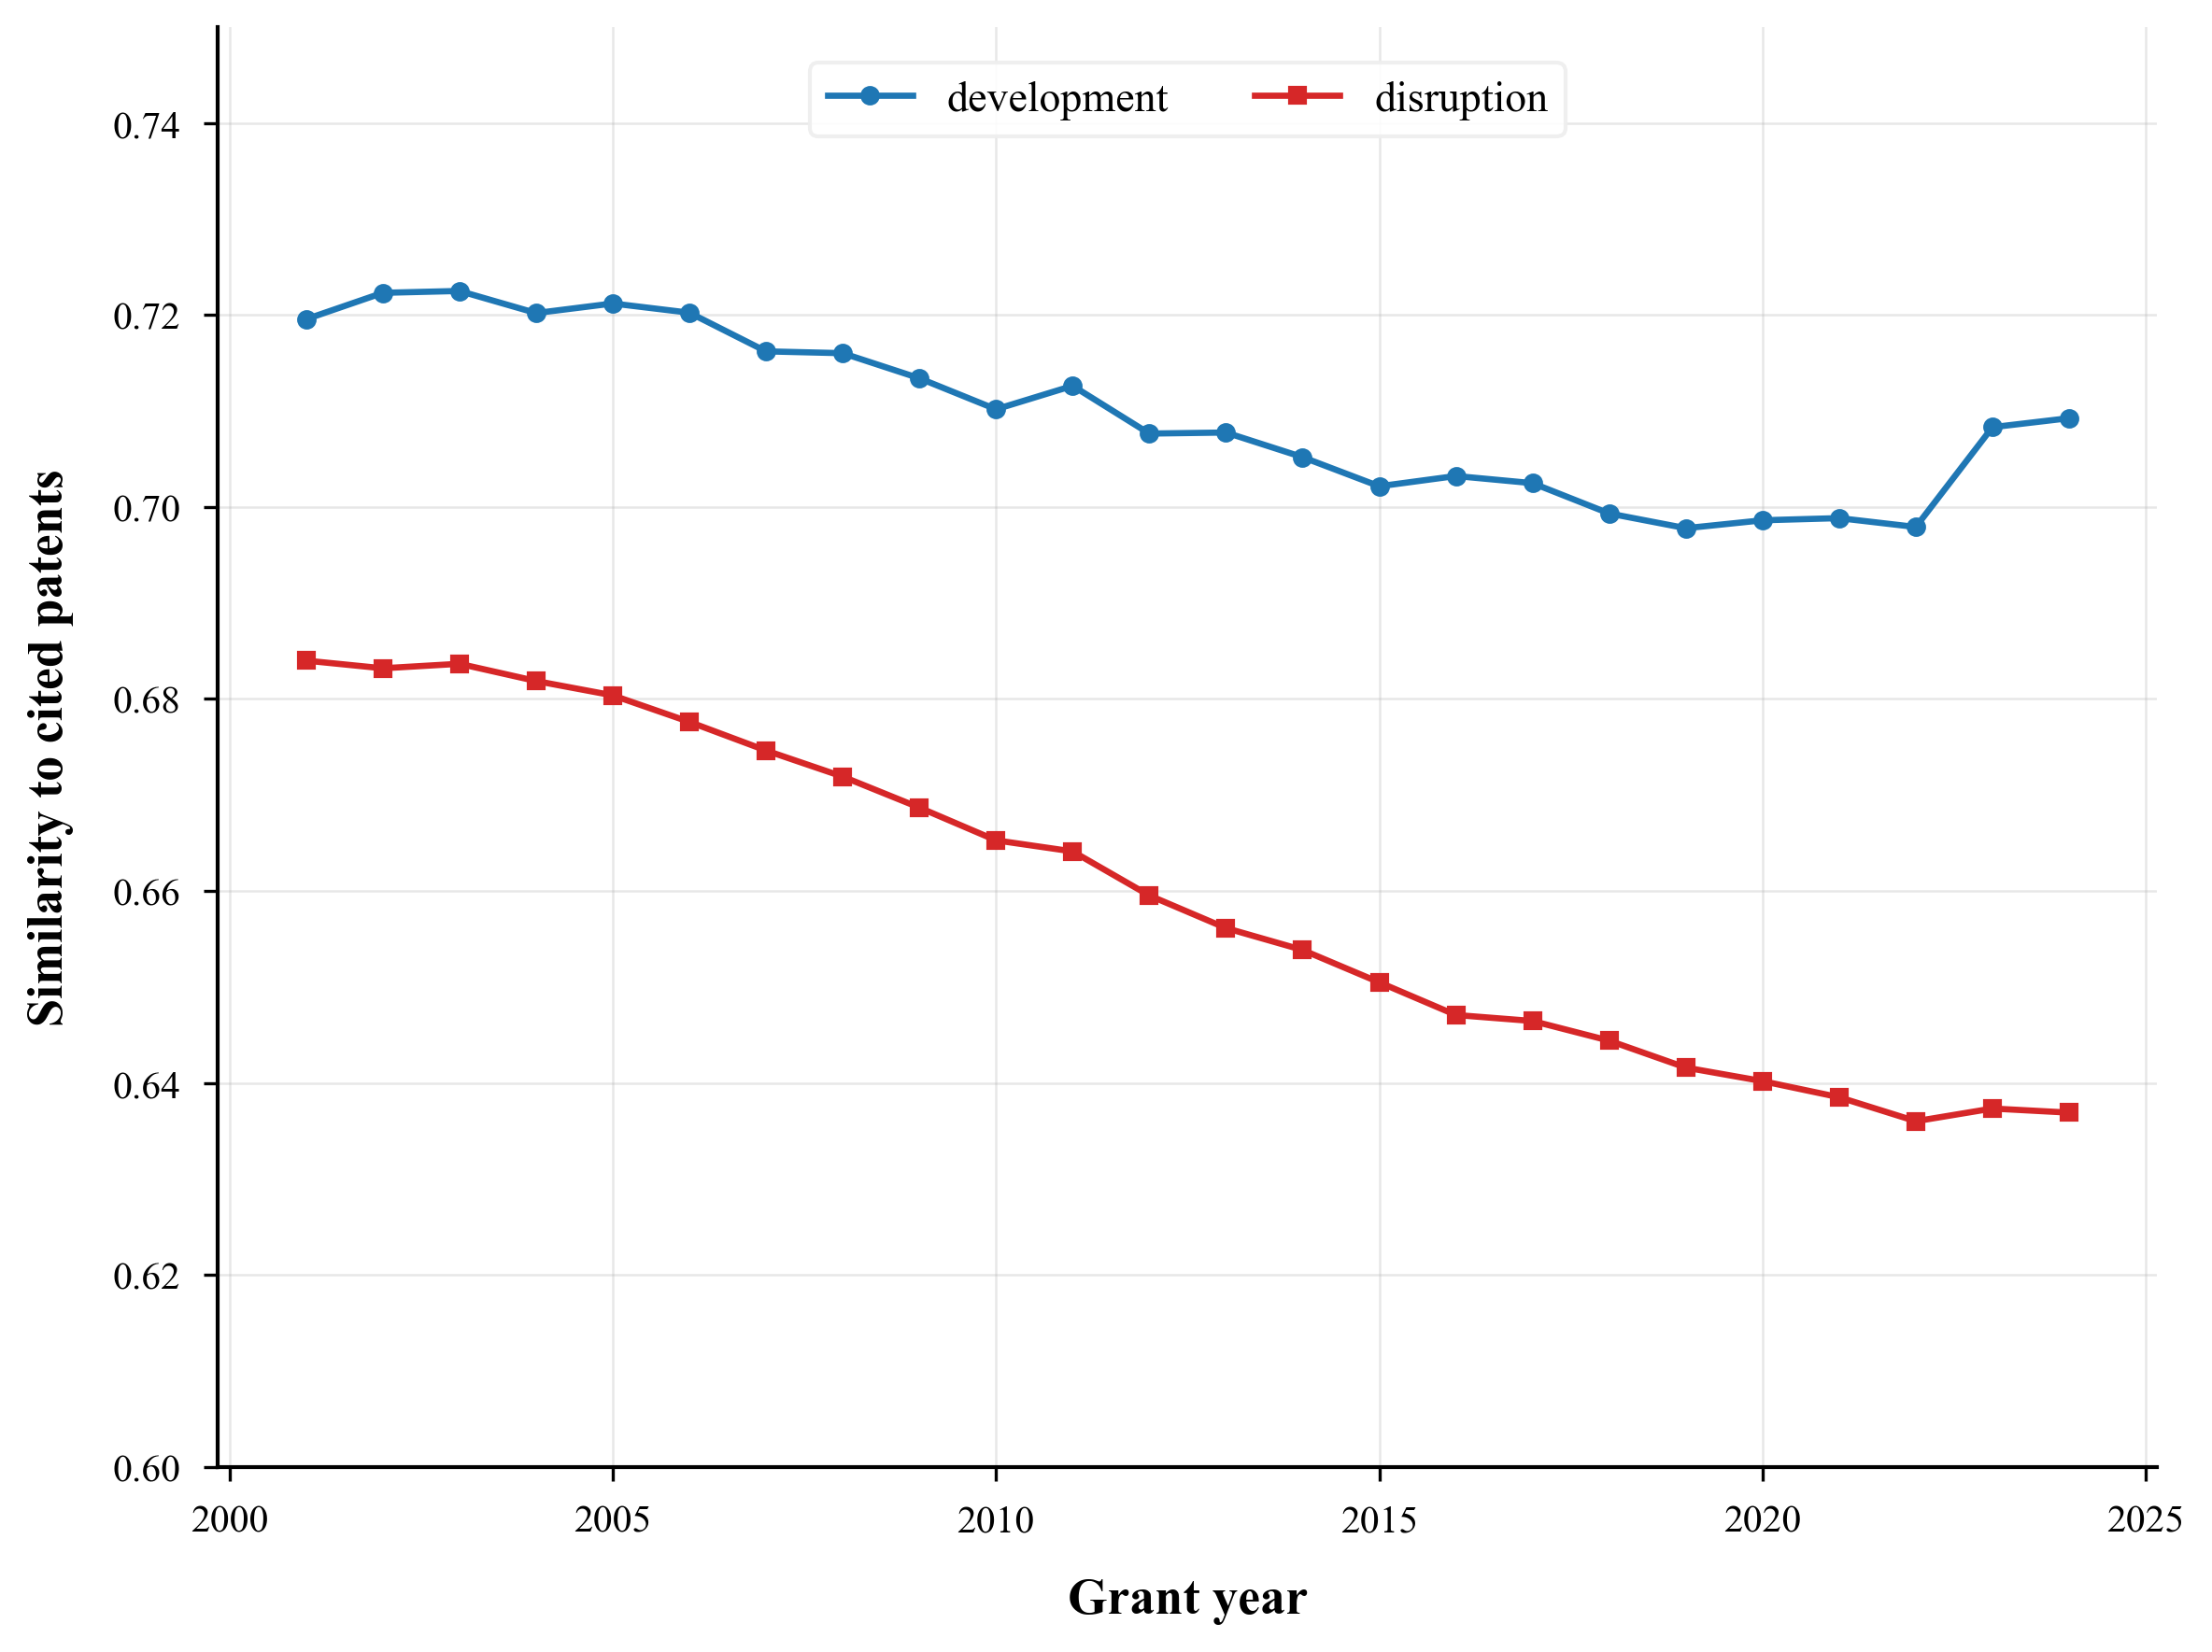

In [51]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=300) 


ax.plot(
    year_sim.index, 
    year_sim['development'],
    color='#1f77b4', 
    marker='o',
    lw=1.6, 
    ms=4, 
    label='development',
    zorder=3  # 折线在最上层
)

ax.plot(
    year_sim.index, 
    year_sim['disruption'],
    color='#d62728', 
    marker='s',
    lw=1.6, 
    ms=4, 
    label='disruption',
    zorder=3  # 折线在最上层
)

# --------------------------
# 原有美化优化（保持不变）
# --------------------------
ax.set_xlabel('Grant year', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Similarity to cited patents', fontsize=13, fontweight='bold', labelpad=10)

# 网格优化
ax.grid(alpha=0.3, lw=0.6, zorder=1)

# 精简边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# 图例优化
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=2,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='#EEEEEE',
)

# 刻度优化
ax.tick_params(axis='x', labelsize=10, pad=6)
ax.tick_params(axis='y', labelsize=10, pad=6)
ax.set_ylim(0.6,0.75)

ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# 释放内存
plt.close('all')

In [52]:
df_merged

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,cites_5yr,is_top,cd5_index,disruption
0,5751830,10000000,0.675,cited by applicant,10000000,2018.0,9.0,0,0.025424,1
1,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0,0.333333,1
2,8124241,10000002,0.709,cited by applicant,10000002,2018.0,0.0,0,0.090909,1
3,9352506,10000003,0.794,cited by applicant,10000003,2018.0,1.0,0,0.222222,1
4,5632133,10000004,0.661,cited by examiner,10000004,2018.0,0.0,0,0.093750,1
...,...,...,...,...,...,...,...,...,...,...
5171992,6584922,9975748,0.796,cited by examiner,9975748,2018.0,0.0,0,0.073171,1
5171993,6173941,9975749,0.805,cited by applicant,9975749,2018.0,1.0,0,-0.156250,0
5171994,6695568,9975750,0.571,cited by applicant,9975750,2018.0,12.0,0,-0.021429,0
5171995,5607004,9975751,0.737,cited by examiner,9975751,2018.0,0.0,0,-0.024390,0


#### 可视化

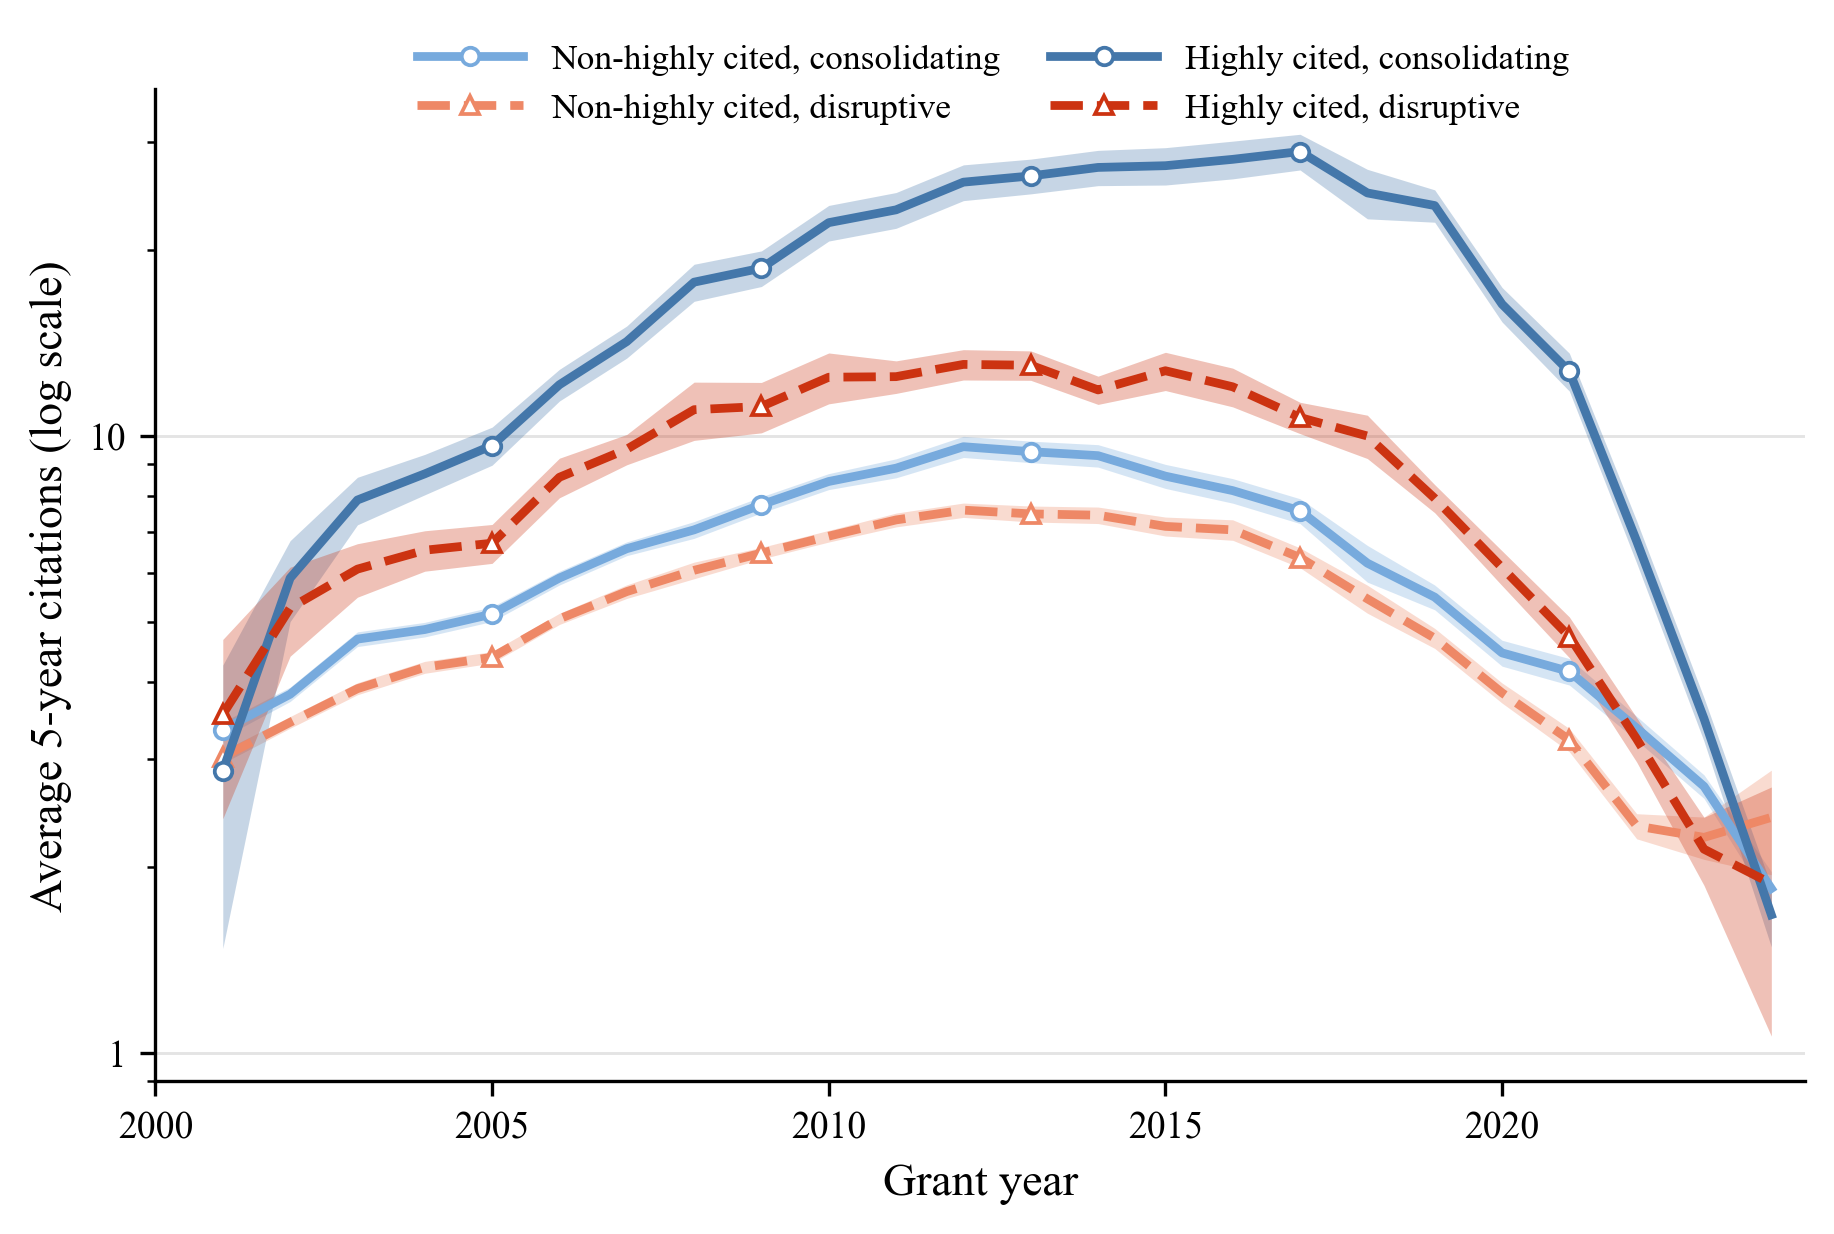

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------------------- 1. Data preparation ----------------------
df_filtered = (
    df_merged.loc[
        df_merged["patent_year"].between(1980, 2024)
    ]
    .copy()
)

# 保留你原来的处理方式
df_filtered["cites_5yr"] = df_filtered["cites_5yr"].replace(0, np.nan)


def calc_mean_ci(df, is_top_val, disruption_val):
    """Calculate annual mean and 95% confidence interval."""
    stats = (
        df.loc[
            (df["is_top"] == is_top_val)
            & (df["disruption"] == disruption_val)
        ]
        .groupby("patent_year")["cites_5yr"]
        .agg(mean="mean", sem="sem", n="count")
        .dropna(subset=["mean", "sem"])
        .sort_index()
    )

    stats["ci_lower"] = stats["mean"] - 1.96 * stats["sem"]
    stats["ci_upper"] = stats["mean"] + 1.96 * stats["sem"]

    # 对数坐标不能显示非正数；不人为设为0.1，而是将其隐藏
    stats.loc[stats["ci_lower"] <= 0, "ci_lower"] = np.nan

    return stats


# ---------------------- 2. Group definitions ----------------------
groups = [
    {
        "is_top": 0,
        "disruption": 0,
        "label": "Non-highly cited, consolidating",
        "color": "#77AADD",   # light blue
        "linestyle": "-",
        "marker": "o",
    },
    {
        "is_top": 0,
        "disruption": 1,
        "label": "Non-highly cited, disruptive",
        "color": "#EE8866",   # light vermillion
        "linestyle": "--",
        "marker": "^",
    },
    {
        "is_top": 1,
        "disruption": 0,
        "label": "Highly cited, consolidating",
        "color": "#4477AA",   # deep blue
        "linestyle": "-",
        "marker": "o",
    },
    {
        "is_top": 1,
        "disruption": 1,
        "label": "Highly cited, disruptive",
        "color": "#CC3311",   # deep vermillion
        "linestyle": "--",
        "marker": "^",
    },
]

# ---------------------- 3. Plot ----------------------
fig, ax = plt.subplots(
    figsize=(6, 4),
    dpi=300,
    constrained_layout=True,
)

for group in groups:
    stats = calc_mean_ci(
        df_filtered,
        group["is_top"],
        group["disruption"],
    )

    x = stats.index.to_numpy()
    mean = stats["mean"].to_numpy()
    lower = stats["ci_lower"].to_numpy()
    upper = stats["ci_upper"].to_numpy()

    # 95% confidence interval
    ax.fill_between(
        x,
        lower,
        upper,
        color=group["color"],
        alpha=0.3,
        linewidth=0,
        zorder=1,
    )

    # Annual mean
    ax.plot(
        x,
        mean,
        label=group["label"],
        color=group["color"],
        linestyle=group["linestyle"],
        linewidth=2.1,
        marker=group["marker"],
        markersize=4.2,
        markevery=4,
        markerfacecolor="white",
        markeredgewidth=0.9,
        zorder=3,
    )


# ---------------------- 4. Appearance ----------------------
ax.set_xlabel("Grant year", fontsize=11)
ax.set_ylabel("Average 5-year citations (log scale)", fontsize=11)

ax.set_xlim(2000.5, 2024.5)
ax.set_xticks(np.arange(2000, 2025, 5))
ax.set_yscale("log")

# 将对数刻度显示为0.1、1、10、100，而不是10的幂
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{value:g}")
)

ax.set_axisbelow(True)
ax.grid(
    axis="y",
    which="major",
    color="#D9D9D9",
    linewidth=0.7,
    alpha=0.7,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=9,
    direction="out",
    length=3.5,
    width=0.8,
)

ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.15, 0.95),
    ncol=2,
    frameon=False,
    fontsize=8.5,
    handlelength=3,
    columnspacing=1.4,
    borderaxespad=0,
)

plt.show()

In [54]:
df_merged['citing_id'] = df_merged['citing_id'].astype('str')
df_merged['cited_id'] = df_merged['cited_id'].astype('str')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15804\2542851425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['citing_id'] = df_merged['citing_id'].astype('str')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15804\2542851425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['cited_id'] = df_merged['cited_id'].astype('str')


#### 去除内部引用

In [22]:
file_path = r'E:\tinierZhao_E_recovery\US-AI-Patents-main\US-AI-Patents-main\g_assignee_disambiguated_20241231.tsv\g_assignee_disambiguated.tsv'  # 替换为你的TSV文件路径

# 读取TSV文件
g_assignee_disambiguated = pd.read_csv(file_path, sep='\t')

# 显示数据框的前几行
g_assignee_disambiguated.head()

,patent_id,assignee_sequence,assignee_id,disambig_assignee_individual_name_first,disambig_assignee_individual_name_last,disambig_assignee_organization,assignee_type,location_id
0,4488683,0,b12aba35-6fdd-4346-b7c0-8c7a157c8844,NaN,NaN,Metal Works Ramat David,3.0,50dc5d46-16c8-11ed-9b5f-1234bde3cd05
1,11872626,0,ee0744f6-d2d4-46f4-8be7-2758e096a6a9,NaN,NaN,"DIVERGENT TECHNOLOGIES, INC.",2.0,15c69712-16c8-11ed-9b5f-1234bde3cd05
2,5856666,0,79f3a1f8-bf1c-41d5-ba18-4f8e7041ebe9,NaN,NaN,U.S. Philips Corporation,2.0,92237ca2-16c8-11ed-9b5f-1234bde3cd05
3,5204210,0,a950758a-0188-4b59-8d8f-2c1a23d0d201,NaN,NaN,Xerox Corporation,2.0,0cd1998f-16c8-11ed-9b5f-1234bde3cd05
4,5302149,1,75d7db10-e04f-434c-afb4-c72688ea244b,NaN,NaN,COMMONWEALTH SCIENTIFIC AND INDUSTRIAL RESEARC...,7.0,4d36742f-16c8-11ed-9b5f-1234bde3cd05


In [55]:
df_assignee_disambiguated = g_assignee_disambiguated[(g_assignee_disambiguated['assignee_sequence'] == 0)][['patent_id','assignee_id']]

In [56]:
df_assignee_disambiguated

,patent_id,assignee_id
0,4488683,b12aba35-6fdd-4346-b7c0-8c7a157c8844
1,11872626,ee0744f6-d2d4-46f4-8be7-2758e096a6a9
2,5856666,79f3a1f8-bf1c-41d5-ba18-4f8e7041ebe9
3,5204210,a950758a-0188-4b59-8d8f-2c1a23d0d201
5,D397841,e0209c8c-78a6-45a2-bcc8-b651b0cf6f88
...,...,...
8385073,11271126,cb93af77-17bd-40f2-8761-7e9028c19fb7
8385074,8328445,6c3354f4-6459-49d8-84fe-c7cb2ed3fb58
8385075,5970411,27eddff9-d99c-49f2-8685-290584b26b78
8385076,9760360,cd032001-d22e-4836-99d2-d13e8a542d60


In [57]:
data_with_cited = pd.merge(
    df_merged,  # 主数据
    df_assignee_disambiguated,  # 专利-公司对照表
    left_on="cited_id",  # 主数据中「被引专利ID」字段
    right_on="patent_id",  # 对照表中「专利ID」字段
    how="left"  # 左连接：保留主数据所有行，无匹配则为NaN
).rename(columns={"assignee_id": "cited_assignee_id"})  # 重命名，避免冲突

# 删除连接时产生的重复patent_id列（来自对照表）
data_with_cited = data_with_cited.drop(columns=["patent_id_y"], errors="ignore")
# 统一主数据patent_id列名（若有需要）
if "patent_id_x" in data_with_cited.columns:
    data_with_cited = data_with_cited.rename(columns={"patent_id_x": "patent_id"})


# 2.2 映射citing_id -> citing_assignee_id（引用专利对应的公司）
data_with_both = pd.merge(
    data_with_cited,  # 已映射cited_assignee的数据
    df_assignee_disambiguated,  # 专利-公司对照表
    left_on="citing_id",  # 主数据中「引用专利ID」字段
    right_on="patent_id",  # 对照表中「专利ID」字段
    how="left"  # 左连接：保留所有行，无匹配则为NaN
).rename(columns={"assignee_id": "citing_assignee_id"})  # 重命名

# 删除重复的patent_id列（来自第二次连接）
data_with_both = data_with_both.drop(columns=["patent_id_y"], errors="ignore")


# ---------------------- 3. 去除自引（核心筛选） ----------------------
# 自引定义：被引专利的公司 == 引用专利的公司（cited_assignee_id == citing_assignee_id）
# 筛选条件：两个公司ID不相等，同时排除公司ID为NaN的情况（避免误判）
non_self_cite = data_with_both[
    (data_with_both["cited_assignee_id"] != data_with_both["citing_assignee_id"]) &
    (data_with_both["cited_assignee_id"].notna()) &
    (data_with_both["citing_assignee_id"].notna())
].reset_index(drop=True)

In [58]:
non_self_cite

,cited_id,citing_id,sim,cited_by,patent_id_x,patent_year,cites_5yr,is_top,cd5_index,disruption,cited_assignee_id,citing_assignee_id
0,5751830,10000000,0.675,cited by applicant,10000000,2018.0,9.0,0,0.025424,1,0bcb0108-ba36-4edb-82e7-cc15abe7a665,a4b14180-6e72-4316-bf91-4f27cdd22bcd
1,9022767,10000001,0.788,cited by examiner,10000001,2018.0,0.0,0,0.333333,1,859ce9c9-0f35-4692-bca1-b2cc38eecc22,0e4eab14-f7af-4d2b-95ab-ef933d1a893b
2,8124241,10000002,0.709,cited by applicant,10000002,2018.0,0.0,0,0.090909,1,31343864-408c-41fe-bf2b-36cd5158a0fa,98b8be72-11fa-4e70-846c-d2d488a1e906
3,8488994,10000010,0.677,cited by examiner,10000010,2018.0,0.0,1,-0.027211,0,bdfca722-17d8-4310-99b9-a424ba166e57,a950758a-0188-4b59-8d8f-2c1a23d0d201
4,9833839,10000011,0.585,cited by examiner,10000011,2018.0,5.0,1,-0.028947,0,a7cdee15-3c4e-43fb-8886-b6d510e42247,9980b396-19f0-4eb1-a395-28e1729f6987
...,...,...,...,...,...,...,...,...,...,...,...,...
3140376,5565660,9975731,0.611,cited by applicant,9975731,2018.0,1.0,0,0.100000,1,c5b6391c-a6da-4b13-828e-7f79db778450,8e1d4a99-3cfe-44e0-bbf2-cb43b41ff183
3140377,6830132,9975733,0.761,cited by examiner,9975733,2018.0,2.0,0,-0.100000,0,2f6d1f39-14ac-4537-9b54-63bc5f88321f,1998fdf3-2d4a-45bb-b04d-270c7d27bf61
3140378,7063306,9975742,0.702,cited by examiner,9975742,2018.0,10.0,0,0.000000,0,912fe99e-f4af-4a6b-b13a-2761a60051cb,58258088-0b71-45ab-87a7-71583e4ef1e4
3140379,6695568,9975750,0.571,cited by applicant,9975750,2018.0,12.0,0,-0.021429,0,13e6fee6-498e-4e3f-8cff-a2328f95b5e0,afd6499b-0a18-48b2-b0c2-0595a6b1ccb8


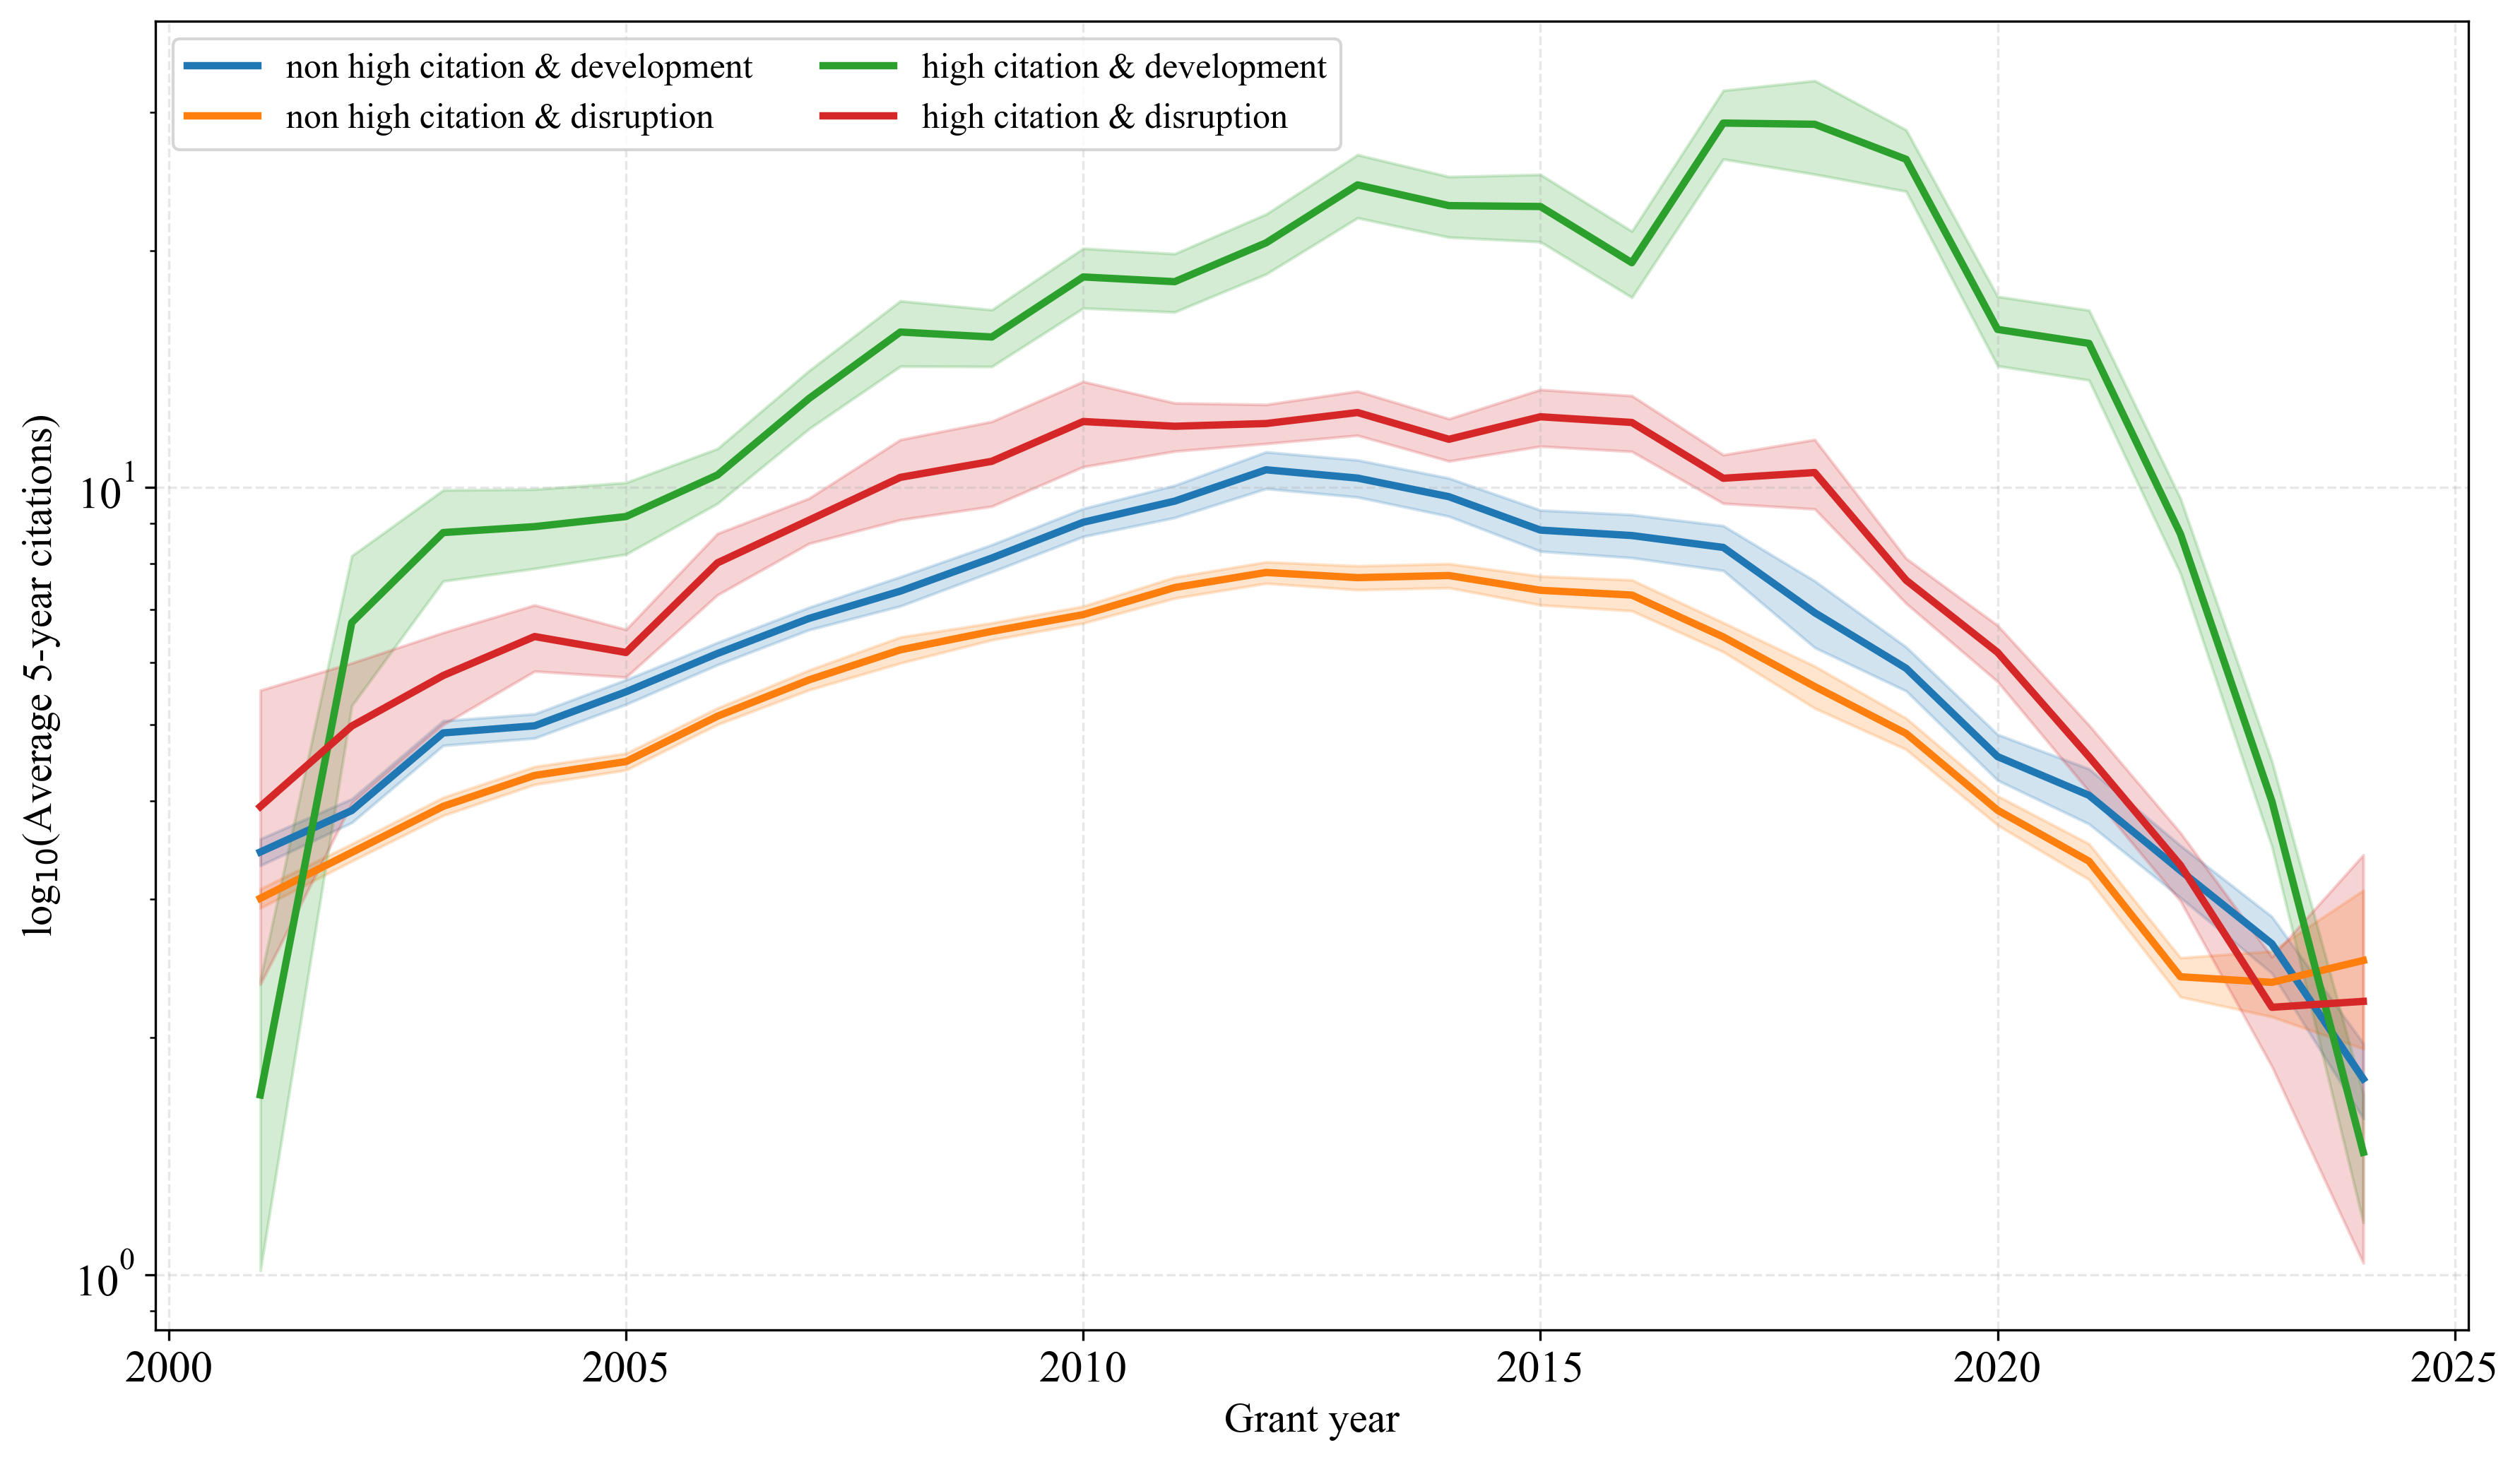

In [59]:
# ---------------------- 1. 数据预处理：计算均值+95%置信区间 ----------------------
df_filtered = non_self_cite.query("1980 <= patent_year <= 2024")
df_filtered = df_filtered.assign(
    cites_5yr=lambda x: np.where(x['cites_5yr'] == 0, np.nan, x['cites_5yr'])
)

# 定义函数：计算「年度均值 + 95%置信区间」
def calc_mean_ci(df, is_top_val, disruption_val):
    stats = (
        df
        .query(f"is_top == {is_top_val} & disruption == {disruption_val}")
        .groupby('patent_year')['cites_5yr']
        .agg(['mean', 'sem'])
        .dropna()
        .sort_index()
    )
    # 95%置信区间 = 均值 ± 1.96×标准误
    z = 1.96
    stats['ci_lower'] = stats['mean'] - z * stats['sem']
    stats['ci_upper'] = stats['mean'] + z * stats['sem']
    # 避免置信区间下限为负（对数坐标下设置最小为0.1）
    stats['ci_lower'] = stats['ci_lower'].clip(lower=0.1)
    return stats

# 四种组合的均值+置信区间
c1 = calc_mean_ci(df_filtered, 0, 0)  # is_top=0, disruption=0
c2 = calc_mean_ci(df_filtered, 0, 1)  # is_top=0, disruption=1
c3 = calc_mean_ci(df_filtered, 1, 0)  # is_top=1, disruption=0
c4 = calc_mean_ci(df_filtered, 1, 1)  # is_top=1, disruption=1

plt.figure(figsize=(12, 7), dpi=300)

# 定义颜色和标记（与示例风格统一）
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels = [
    'is_top=0, disruption=0',
    'is_top=0, disruption=1',
    'is_top=1, disruption=0',
    'is_top=1, disruption=1'
]

# 组合1：is_top=0, disruption=0
plt.plot(c1.index, c1['mean'], color=colors[0], lw=2.5, label='non high citation & development')
plt.fill_between(
    c1.index, c1['ci_lower'], c1['ci_upper'], 
    color=colors[0], alpha=0.2, zorder=1  # 透明度0.2，保证线在填充带上方
)

# 组合2：is_top=0, disruption=1
plt.plot(c2.index, c2['mean'], color=colors[1], lw=2.5, label='non high citation & disruption')
plt.fill_between(
    c2.index, c2['ci_lower'], c2['ci_upper'], 
    color=colors[1], alpha=0.2, zorder=1
)

# 组合3：is_top=1, disruption=0
plt.plot(c3.index, c3['mean'], color=colors[2], lw=2.5, label='high citation & development')
plt.fill_between(
    c3.index, c3['ci_lower'], c3['ci_upper'], 
    color=colors[2], alpha=0.2, zorder=1
)

# 组合4：is_top=1, disruption=1
plt.plot(c4.index, c4['mean'], color=colors[3], lw=2.5, label='high citation & disruption')
plt.fill_between(
    c4.index, c4['ci_lower'], c4['ci_upper'], 
    color=colors[3], alpha=0.2, zorder=1
)

# 图表美化（与示例风格统一）
plt.xlabel('Grant year', fontsize=14)
plt.ylabel('log$_{10}$(Average 5-year citations)', fontsize=14)
plt.yscale('log')  # 对数纵坐标
plt.legend(fontsize=12,ncol=2)
plt.grid(alpha=0.3, linestyle='--', zorder=0)  # 网格在填充带下方
plt.tight_layout()


# 显示/保存
plt.show()

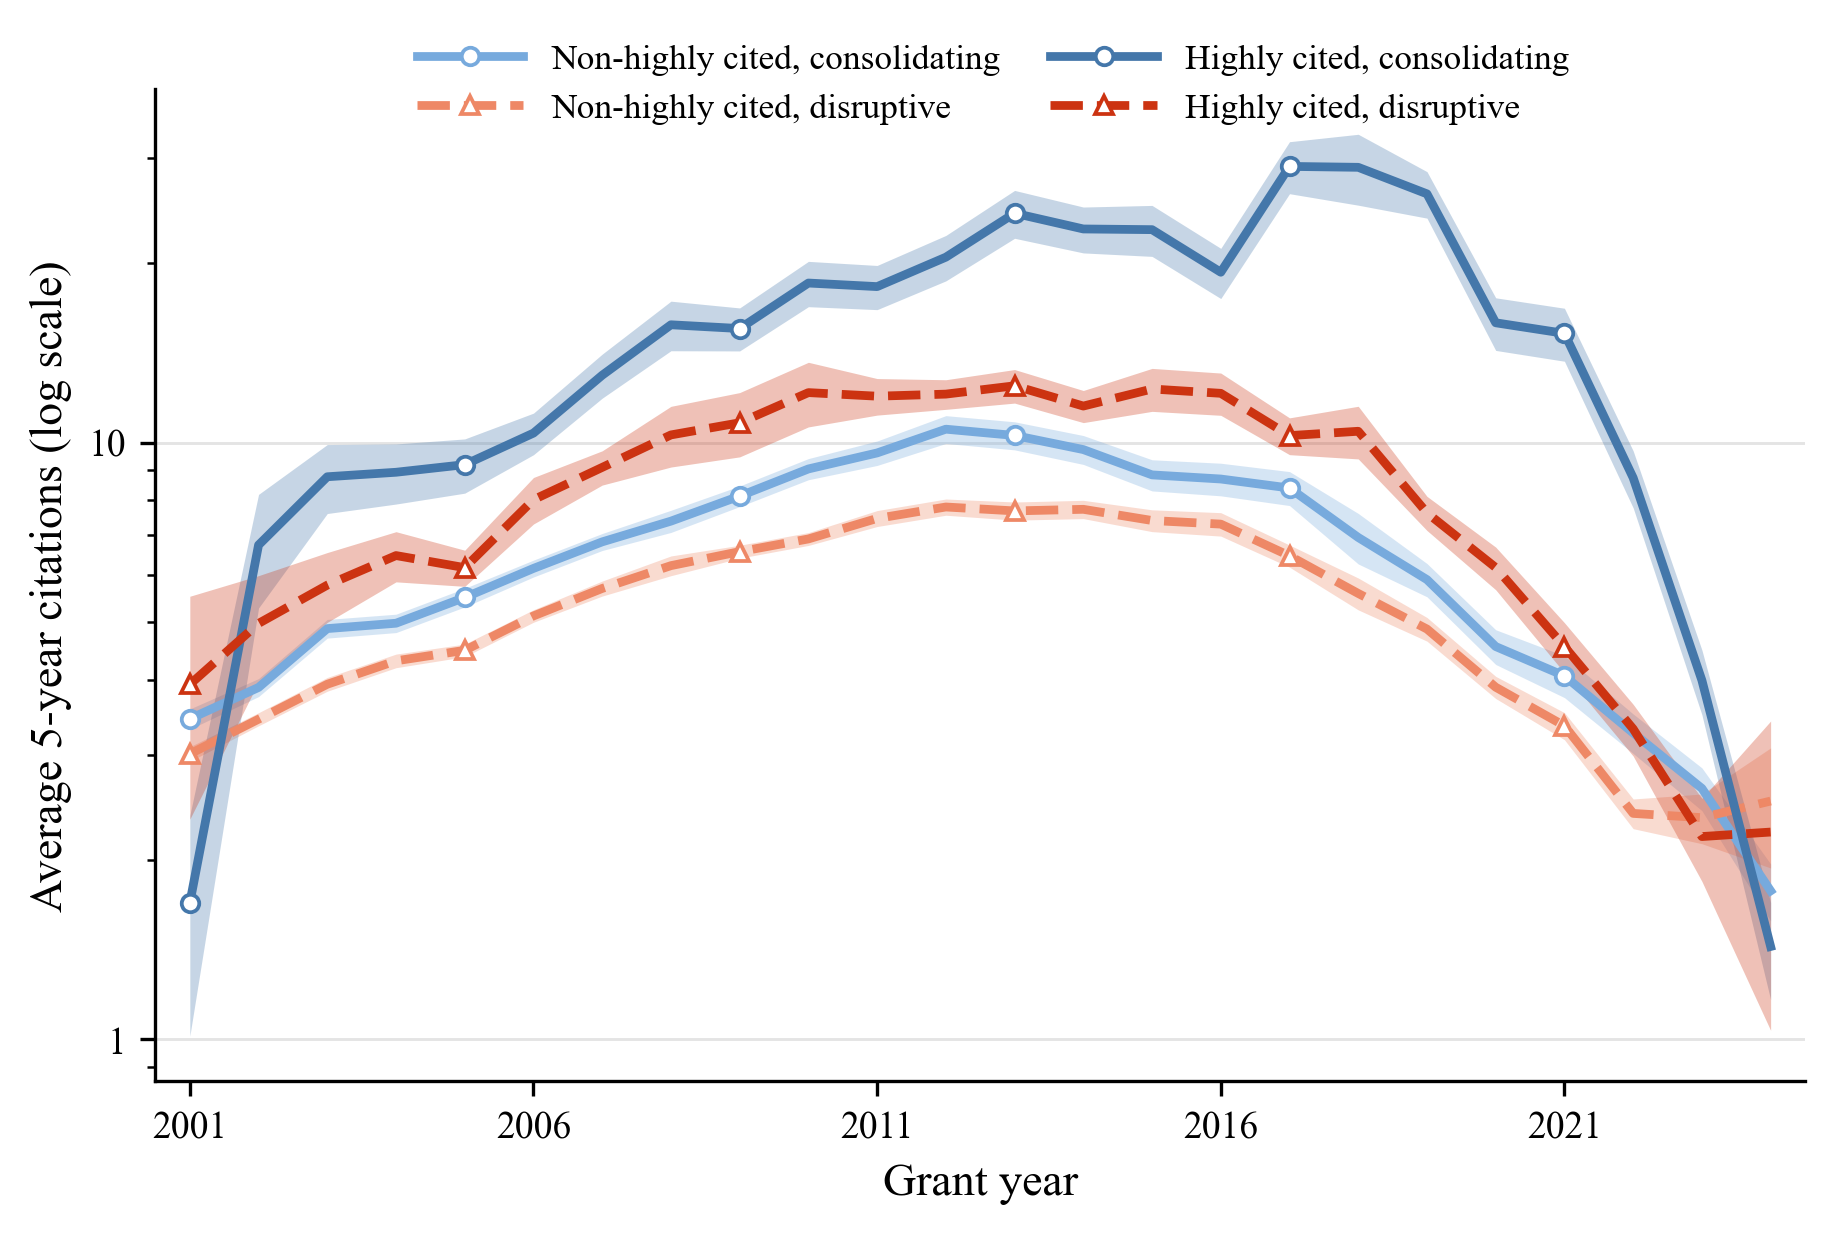

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------------------- 1. Data preparation ----------------------
df_filtered = non_self_cite.query("1980 <= patent_year <= 2024")
df_filtered = df_filtered.assign(
    cites_5yr=lambda x: np.where(x['cites_5yr'] == 0, np.nan, x['cites_5yr'])
)

def calc_mean_ci(df, is_top_val, disruption_val):
    """Calculate annual mean and 95% confidence interval."""
    stats = (
        df.loc[
            (df["is_top"] == is_top_val)
            & (df["disruption"] == disruption_val)
        ]
        .groupby("patent_year")["cites_5yr"]
        .agg(mean="mean", sem="sem", n="count")
        .dropna(subset=["mean", "sem"])
        .sort_index()
    )

    stats["ci_lower"] = stats["mean"] - 1.96 * stats["sem"]
    stats["ci_upper"] = stats["mean"] + 1.96 * stats["sem"]

    # 对数坐标不能显示非正数；不人为设为0.1，而是将其隐藏
    stats.loc[stats["ci_lower"] <= 0, "ci_lower"] = np.nan

    return stats


# ---------------------- 2. Group definitions ----------------------
groups = [
    {
        "is_top": 0,
        "disruption": 0,
        "label": "Non-highly cited, consolidating",
        "color": "#77AADD",   # light blue
        "linestyle": "-",
        "marker": "o",
    },
    {
        "is_top": 0,
        "disruption": 1,
        "label": "Non-highly cited, disruptive",
        "color": "#EE8866",   # light vermillion
        "linestyle": "--",
        "marker": "^",
    },
    {
        "is_top": 1,
        "disruption": 0,
        "label": "Highly cited, consolidating",
        "color": "#4477AA",   # deep blue
        "linestyle": "-",
        "marker": "o",
    },
    {
        "is_top": 1,
        "disruption": 1,
        "label": "Highly cited, disruptive",
        "color": "#CC3311",   # deep vermillion
        "linestyle": "--",
        "marker": "^",
    },
]

# ---------------------- 3. Plot ----------------------
fig, ax = plt.subplots(
    figsize=(6, 4),
    dpi=300,
    constrained_layout=True,
)

for group in groups:
    stats = calc_mean_ci(
        df_filtered,
        group["is_top"],
        group["disruption"],
    )

    x = stats.index.to_numpy()
    mean = stats["mean"].to_numpy()
    lower = stats["ci_lower"].to_numpy()
    upper = stats["ci_upper"].to_numpy()

    # 95% confidence interval
    ax.fill_between(
        x,
        lower,
        upper,
        color=group["color"],
        alpha=0.3,
        linewidth=0,
        zorder=1,
    )

    # Annual mean
    ax.plot(
        x,
        mean,
        label=group["label"],
        color=group["color"],
        linestyle=group["linestyle"],
        linewidth=2.1,
        marker=group["marker"],
        markersize=4.2,
        markevery=4,
        markerfacecolor="white",
        markeredgewidth=0.9,
        zorder=3,
    )


# ---------------------- 4. Appearance ----------------------
ax.set_xlabel("Grant year", fontsize=11)
ax.set_ylabel("Average 5-year citations (log scale)", fontsize=11)

ax.set_xlim(2000.5, 2024.5)
ax.set_xticks(np.arange(2001, 2024, 5))
ax.set_yscale("log")

# 将对数刻度显示为0.1、1、10、100，而不是10的幂
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{value:g}")
)

ax.set_axisbelow(True)
ax.grid(
    axis="y",
    which="major",
    color="#D9D9D9",
    linewidth=0.7,
    alpha=0.7,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=9,
    direction="out",
    length=3.5,
    width=0.8,
)

ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.15, 0.95),
    ncol=2,
    frameon=False,
    fontsize=8.5,
    handlelength=3,
    columnspacing=1.4,
    borderaxespad=0,
)

plt.show()

##### 添加控制变量

In [61]:
control_variables = pd.read_csv(r'E:\tinierZhao_E_recovery\US-AI-Patents-main\US-AI-Patents-main\patent_control_variable\result\control_variables.csv')

In [62]:
control_variables

,patent_id,wipo_kind,num_claims,patent_year,wipo_field_id,inventor_count,ipc_class_count,num_references
0,10000000,B2,20,2018,10,1,2,2
1,10000001,B2,12,2018,29,2,3,6
2,10000002,B2,9,2018,21,4,6,3
3,10000003,B2,18,2018,29,3,7,4
4,10000004,B2,6,2018,29,2,4,2
...,...,...,...,...,...,...,...,...
7469932,9999995,B2,5,2018,29,2,3,6
7469933,9999996,B2,9,2018,23,2,3,4
7469934,9999997,B2,18,2018,26,3,3,14
7469935,9999998,B2,13,2018,29,1,4,1


In [63]:
control_variables['patent_id'] = control_variables['patent_id'].astype('str')

In [ ]:
data_stata = pd.merge(
    non_self_cite[['patent_id_x','sim','cites_5yr','is_top','cd5_index','disruption']],  # 主数据
    control_variables,  # 专利-公司对照表
    left_on="patent_id_x",  # 主数据中「被引专利ID」字段
    right_on="patent_id",  # 对照表中「专利ID」字段
    how="left"  # 左连接：保留主数据所有行，无匹配则为NaN
)

In [35]:
data_stata.dropna(inplace=True)

In [109]:
data_stata.to_csv('./citations_result/stata_0629.csv',index=False)

In [36]:
data_stata.to_csv('./citations_result/stata_0707_robust.csv',index=False)

In [3]:
# 读取
data_stata = pd.read_csv('./citations_result/stata_1115.csv')

In [34]:
data_stata

,patent_id_x,sim,cites_5yr,is_top,cd5_index,disruption,patent_id,wipo_kind,num_claims,patent_year,wipo_field_id,inventor_count,ipc_class_count,num_references
0,10000000,0.675,9.0,0,0.025424,1,10000000,B2,20.0,2018.0,10.0,1.0,2.0,2.0
1,10000001,0.788,0.0,0,0.333333,1,10000001,B2,12.0,2018.0,29.0,2.0,3.0,6.0
2,10000002,0.709,0.0,0,0.090909,1,10000002,B2,9.0,2018.0,21.0,4.0,6.0,3.0
3,10000010,0.677,0.0,1,-0.027211,0,10000010,B2,20.0,2018.0,29.0,5.0,2.0,9.0
4,10000011,0.585,5.0,0,-0.028947,0,10000011,B1,30.0,2018.0,29.0,1.0,4.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3140376,9975731,0.611,1.0,0,0.100000,1,9975731,B2,15.0,2018.0,25.0,2.0,1.0,2.0
3140377,9975733,0.761,2.0,0,-0.100000,0,9975733,B2,12.0,2018.0,25.0,2.0,1.0,30.0
3140378,9975742,0.702,10.0,0,0.000000,0,9975742,B1,32.0,2018.0,25.0,2.0,1.0,35.0
3140379,9975750,0.571,12.0,0,-0.021429,0,9975750,B2,34.0,2018.0,25.0,4.0,4.0,29.0


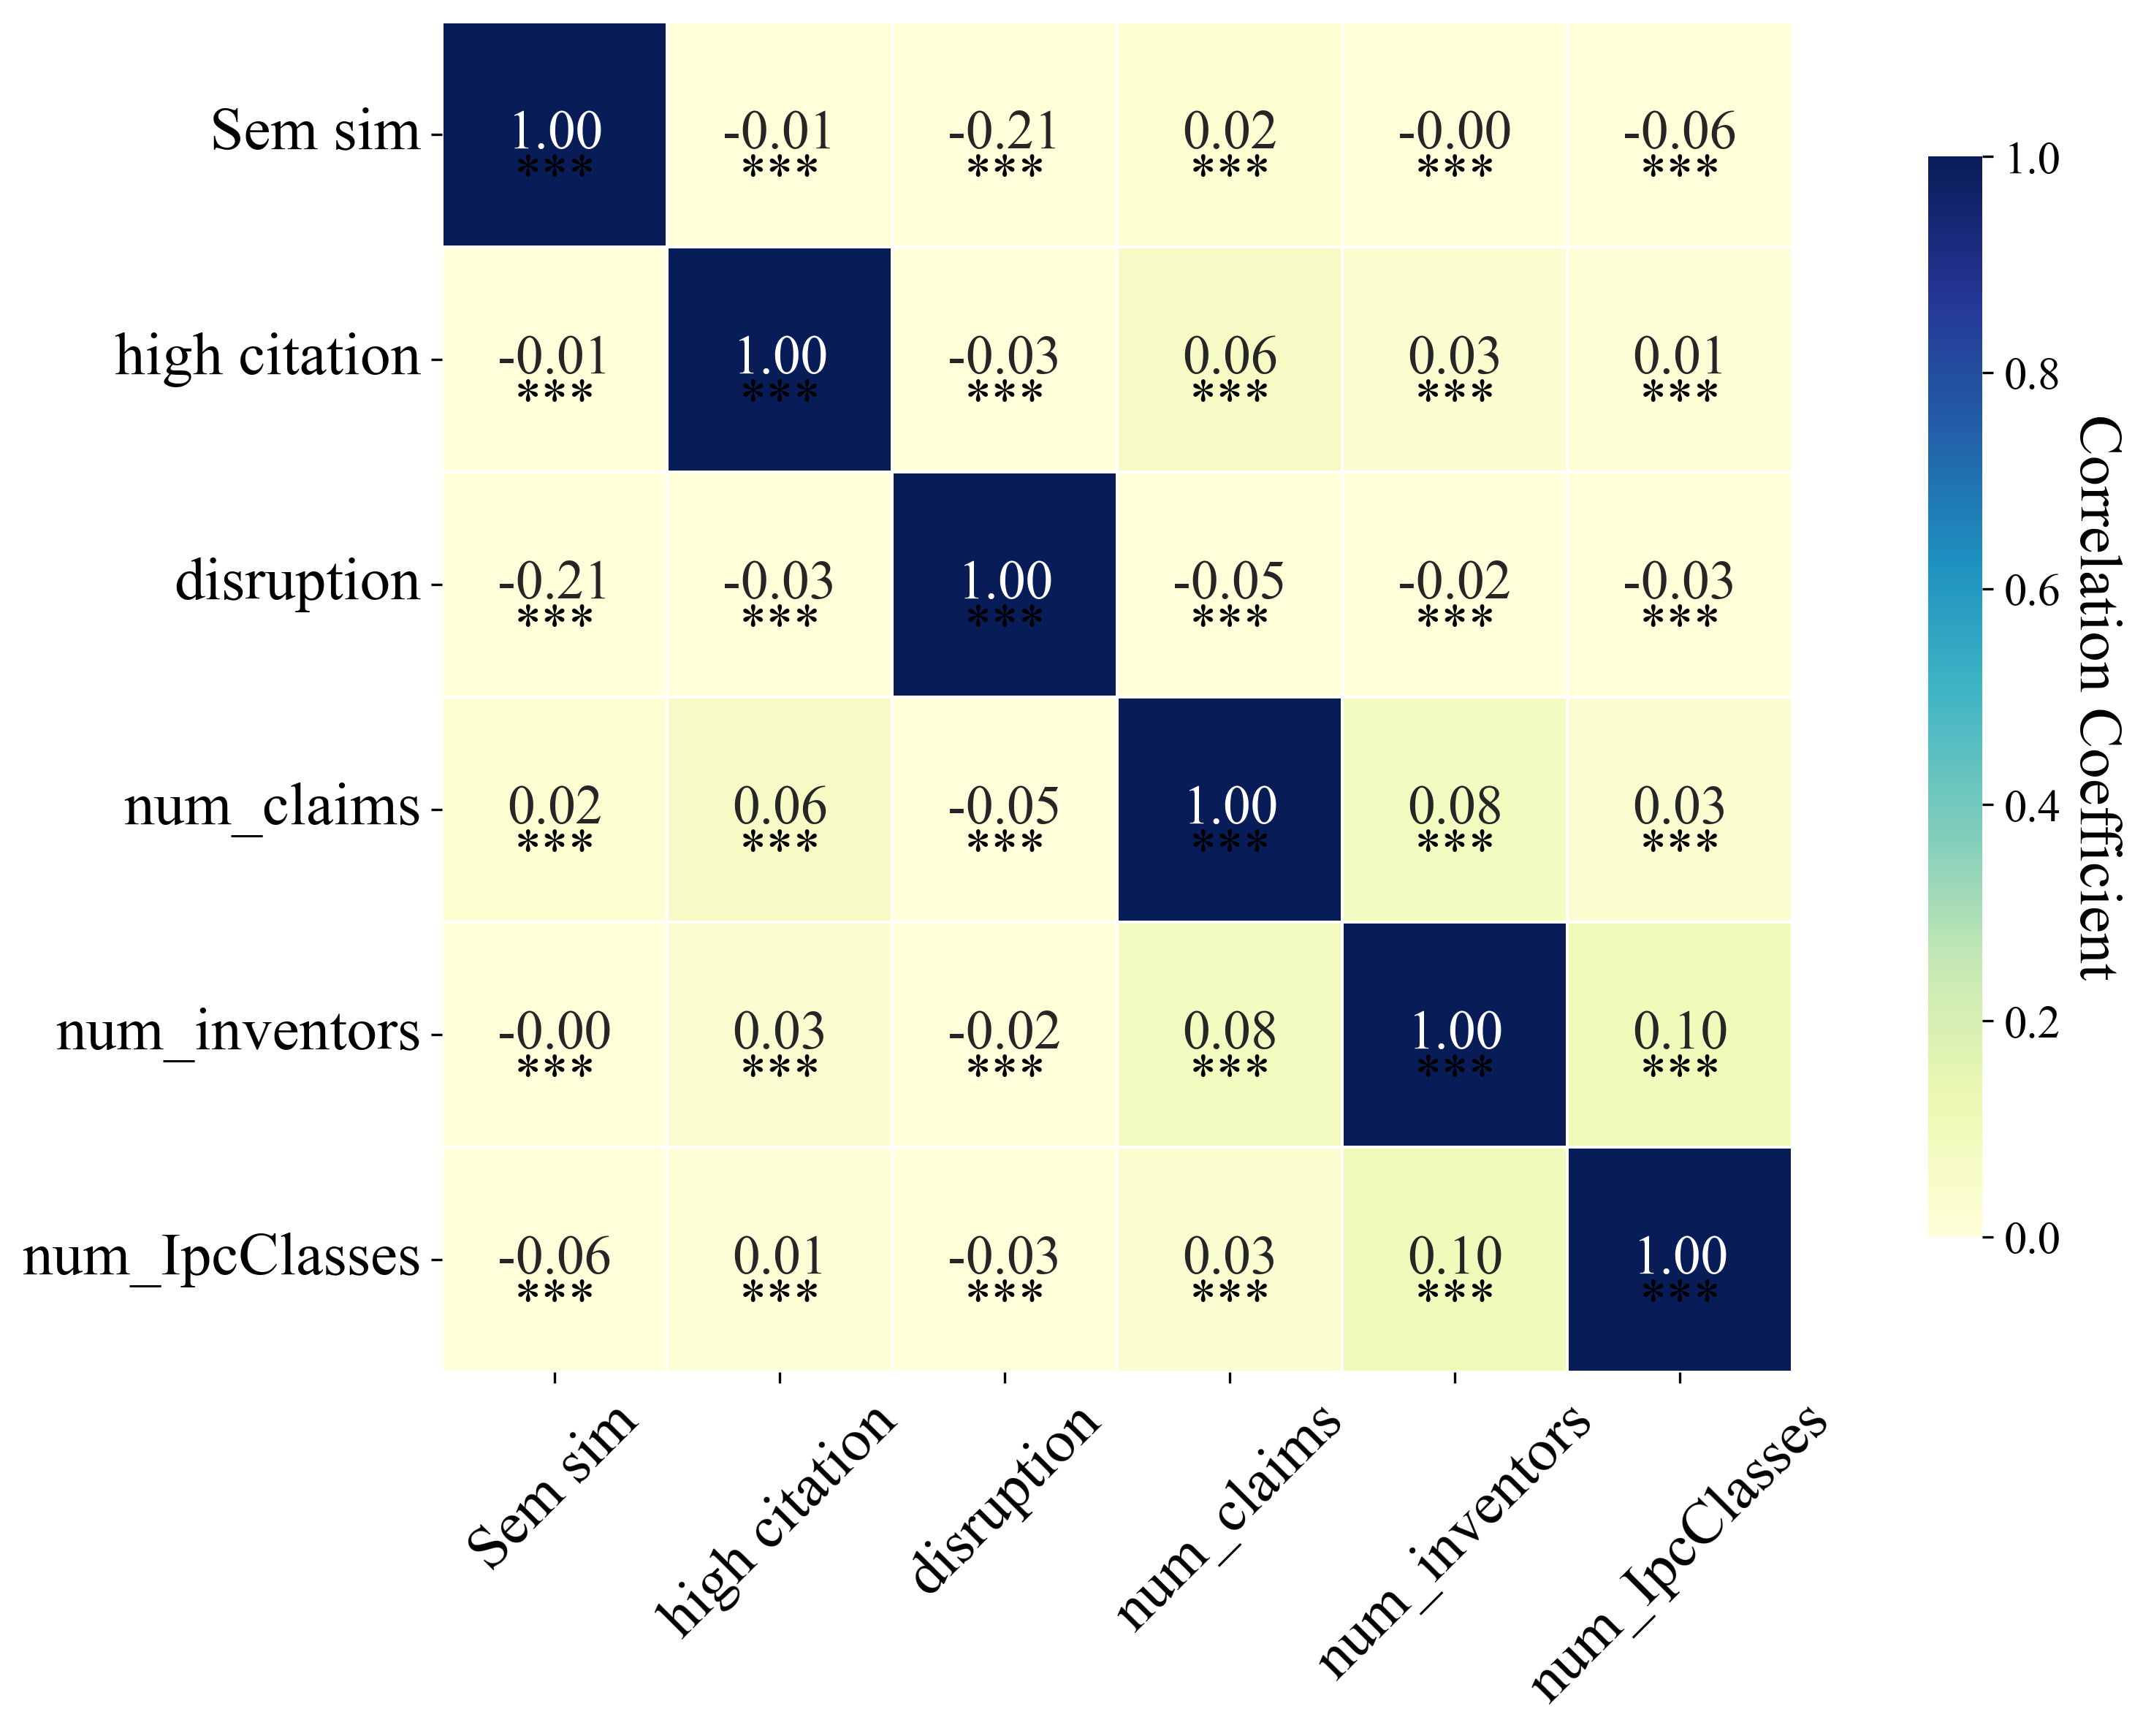

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# 删除包含 NaN 的行
df_cleaned = data_stata[['sim', 'is_top', 'disruption', 
                 'num_claims', 'inventor_count','ipc_class_count']].dropna()

# 计算相关性矩阵
correlation_matrix = df_cleaned.corr()

# 计算 p 值矩阵
p_values = np.ones_like(correlation_matrix, dtype=float)
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        _, p_values[i, j] = pearsonr(df_cleaned.iloc[:, i], df_cleaned.iloc[:, j])

# 将 p 值转换为星号表示
p_star_matrix = np.full_like(correlation_matrix, '', dtype=object)
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        p_val = p_values[i, j]
        if p_val < 0.001:
            p_star_matrix[i, j] = '***'
        elif p_val < 0.01:
            p_star_matrix[i, j] = '**'
        elif p_val < 0.05:
            p_star_matrix[i, j] = '*'
        else:
            p_star_matrix[i, j] = 'n.s.'

# 自定义横纵坐标名
column_names = ['Sem sim', 'high citation', 'disruption','num_claims', 'num_inventors','num_IpcClasses']

# 创建热图
plt.figure(figsize=(16, 8), dpi=300)

# 绘制相关性热图（只显示相关性系数）
ax = sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', square=True, fmt='.2f', linewidths=0.5, cbar_kws={'shrink': .8}, annot_kws={'size': 18},
            xticklabels=column_names, yticklabels=column_names,vmin=0, vmax=1.0)

# 在相关性值下方显示星号矩阵
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        if p_star_matrix[i, j] != 'n.s.':  # 只有显著性星号才显示
            plt.text(j + 0.5, i + 0.7, p_star_matrix[i, j], ha='center', va='center', fontsize=18, color='black')


# 添加相关系数色块条标签
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)  # 这里设置字体大小为10，
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20, size=20)


# 旋转横坐标标签 45°
plt.xticks(rotation=45,fontsize=20)
plt.yticks(rotation=0,fontsize=20)

# 显示图像
plt.show()